In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # or 'Noto Sans TC'
plt.rcParams['axes.unicode_minus'] = False
# import warnings
# warnings.filterwarnings("ignore", category=FutureWarning)


In [2]:
# df = pd.read_spss(r"C:\Users\User\Downloads\D00224_2\data.sav")
# df.to_csv('Dataset.csv', encoding='utf-8-sig', index=False)
df = pd.read_csv(r"C:\Users\User\Documents\GitHub\psychic-spoon\0 2025資料科學漫步\Dataset.csv")
df = df[df['rq21a'] == '答對'].reset_index(drop=True) # 篩選有效樣本中的注意力題答對的樣本
df.shape

(685, 211)

---
---
## 基本資料

In [3]:
individual = df.iloc[:,4:10]
individual['q3'] = individual['q3'].str.replace(r'^\(\d+\)', '', regex=True)
individual['q4'] = individual['q4'].str.replace(r'^\(\d+\)', '', regex=True)

# rename_ = {'q1':'性別', 'q2':'出生年','q3':'出生縣市', 'q4':'學歷'}
# individual = individual.rename(columns=rename_).drop(columns=['q3_other', 'q4_88_text'])
individual = individual.drop(columns=['q3_other', 'q4_88_text'])

individual.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685 entries, 0 to 684
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   q1      685 non-null    object 
 1   q2      685 non-null    float64
 2   q3      685 non-null    object 
 3   q4      685 non-null    object 
dtypes: float64(1), object(3)
memory usage: 21.5+ KB


In [4]:
individual['birthyear_ad'] = individual['q2']+1911
individual['age'] = 2021-individual['birthyear_ad']
bins = [0, 29, 44, 59, 120]
labels = ['青年', '壯年', '中年', '老年']
individual['age_g'] = pd.cut(individual['age'], bins=bins, labels=labels, right=True)
def edu_group(x):
    if x in ["國(初)中"]:
        return "國中以下"
    elif x in ["高職(高商、高工)", "高中職業科", "高中普通科", "軍警專修班", "軍警專科班", "二專", "三專", "五專", "空中行專"]:
        return "高中職"
    elif x in ["大學", "技術學院、科大", "空中大學", "軍警官校或大學"]:
        return "大學"
    elif x in ["碩士", "博士"]:
        return "研究所以上"
    else:
        return None

individual["edu_g"] = individual["q4"].apply(edu_group)
individual

,q1,q2,q3,q4,birthyear_ad,age,age_g,edu_g
0,女,54.0,台北市,碩士,1965.0,56.0,中年,研究所以上
1,男,58.0,台北市,博士,1969.0,52.0,中年,研究所以上
2,女,73.0,新北市,碩士,1984.0,37.0,壯年,研究所以上
3,男,86.0,台北市,碩士,1997.0,24.0,青年,研究所以上
4,女,85.0,台北市,大學,1996.0,25.0,青年,大學
...,...,...,...,...,...,...,...,...
680,男,87.0,高雄市,大學,1998.0,23.0,青年,大學
681,女,81.0,屏東縣,大學,1992.0,29.0,青年,大學
682,女,76.0,屏東縣,碩士,1987.0,34.0,壯年,研究所以上
683,女,83.0,屏東縣,大學,1994.0,27.0,青年,大學


## 網路使用行為

In [5]:
# internet_usage = df.iloc[:,11:59]

# internet_usage['q6'] = np.round((internet_usage['q6_h'] + internet_usage['q6_m']/60), 4)
# internet_usage['q7'] = np.round((internet_usage['q7_h'] + internet_usage['q7_m']/60), 4)
# cols =  internet_usage.columns.tolist()
# i ,j = cols.index('q6_h'), cols.index('q6')
# cols[i], cols[j] = cols[j], cols[i]
# i ,j = cols.index('q6_m'), cols.index('q7')
# cols[i], cols[j] = cols[j], cols[i]
# internet_usage = internet_usage[cols].drop(columns=['q6_h', 'q6_m', 'q7_h', 'q7_m'])

# internet_usage_col_replace = {
#                         'q8_1': '(01)維繫友誼與他人保持聯絡(傳LINE、滑臉書等)',
#                         'q8_2': '(02)娛樂消遣(玩遊戲、看卡通動漫、看電影、戲劇、看直播、聽音樂、交友軟體、追星、命理占卜、打發時間、無聊)',
#                         'q8_3': '(03)獲得時事/新聞/政府資訊(搜尋關鍵字、看新聞、看政府資訊、天氣資訊)',
#                         'q8_4': '(04)獲得生活休閒資訊(美食、觀光旅遊、醫療衛生保健、家庭生活、親子婚姻關係、交通資訊)',
#                         'q8_5': '(05)理財消費購物(看理財資訊、網路購物、理財管理、繳費、財經股市)',
#                         'q8_6': '(06)學習或工作(有支薪)(語言學習、線上課程、使用文書處理軟體、學習各種軟體)',    
                        
#                         'q9_1': '(01)LINE',
#                         'q9_2': '(02)Facebook Messenger(臉書聊天室)',
#                         'q9_3': '(03)微信Wechat',
#                         'q9_4': '(04)WhatsApp',
#                         'q9_5': '(05)Hangouts',
#                         'q9_6': '(06)Skype',
#                         'q9_7': '(07)Facetime',
#                         'q9_8': '(08)Telegram',
#                         'q9_88': '(88)其他',

#                         'q10_1': '(01)臉書(Facebook)',
#                         'q10_2': '(02)Instagram',
#                         'q10_3': '(03)推特(Twitter)',
#                         'q10_4': '(04)LinkedIn',
#                         'q10_5': '(05)微博',
#                         'q10_6': '(06)噗浪(Plurk)',
#                         'q10_7': '(07)抖音(TikTok)',
#                         'q10_8': '(08)PTT',
#                         'q10_9': '(09)Dcard',
#                         'q10_10': '(10)Pinterest',
#                         'q10_88': '(88)其他',

#                         'q11_1': '(01)YouTube',
#                         'q11_2': '(02)愛奇藝',
#                         'q11_3': '(03)Netflix 網飛',
#                         'q11_4': '(04)KKTV',
#                         'q11_5': '(05)LINE TV',
#                         'q11_6': '(06)Li TV',
#                         'q11_7': '(07)Twitch',
#                         'q11_8': '(08)friDay影音',
#                         'q11_88': '(88)其他'
#                         }

# def replace_(df, col_map):
#     for col, text in col_map.items():
#         x = df[col].replace(text, 1)
#         x = x.infer_objects(copy=False)
#         x = x.fillna(0)
#         df[col] = x.astype(int)
# replace_(internet_usage, internet_usage_col_replace)

# rename_ = {'q5_1':'每週平均上網天數',
#            'q6':'一天因工作或課業上網小時','q7':'一天因其他所需上網小時',
#            'q8_1':'因維繫友誼與他人保持聯絡上網', 'q8_2':'因娛樂消遣上網', 'q8_3':'因獲得時事/新聞/政府資訊上網', 'q8_4':'因獲得生活休閒資訊上網', 'q8_5':'因理財消費購物上網', 'q8_6':'因學習或工作上網',
#            'q9_1':'最近一個月使用line', 'q9_2':'最近一個月使用Messenger(臉書聊天室)', 'q9_3':'最近一個月使用微信Wechat', 'q9_4':'最近一個月使用WhatsApp', 'q9_5':'最近一個月使用Hangouts', 'q9_6':'最近一個月使用Skype', 'q9_7':'最近一個月使用Facetime', 'q9_8':'最近一個月使用Telegram', 'q9_88':'最近一個月使用其他即時通訊軟體',
#            'q10_1':'最近一個月使用臉書(Facebook)', 'q10_2':'最近一個月使用Instagram', 'q10_3':'最近一個月使用推特(Twitter)', 'q10_4':'最近一個月使用LinkedIn', 'q10_5':'最近一個月使用微博', 'q10_6':'最近一個月使用噗浪(Plurk)', 'q10_7':'最近一個月使用抖音(TikTok)', 'q10_8':'最近一個月使用PTT', 'q10_9':'最近一個月使用Dcard', 'q10_10':'最近一個月使用Pinterest', 'q10_88':'最近一個月使用其他社群媒體',
#            'q11_1':'最近一個月使用YouTube', 'q11_2':'最近一個月使用)愛奇藝', 'q11_3':'最近一個月使用Netflix 網飛', 'q11_4':'最近一個月使用KKTV', 'q11_5':'最近一個月使用LINE TV', 'q11_6':'最近一個月使用Li TV', 'q11_7':'最近一個月使用Twitch', 'q11_8':'最近一個月使用friDay影音', 'q11_88':'最近一個月使用其他影音平台'}
# internet_usage = internet_usage.rename(columns=rename_).drop(columns=['q8_88', 'q8_88_text', 'q8_90', 'q9_88_text', 'q9_90', 'q10_88_text', 'q10_90', 'q11_88_text', 'q11_90'])
# internet_usage.info()

---
---

## 網路攻擊行為

- 'q22_01_1':'多常在網路上看到別人留言髒話/不好聽的話'
- 'q22_02_1':'多常在網路上看別人兇激怒他的人'
- 'q22_03_1':'多常在網路上看到別人罵討厭他的人'
- 'q22_04_1':'多常在網路上看到別人開不雅玩笑'
- 'q22_05_1':'多常在網路上看到別人用諷刺方式回覆他人',
- 'q23_01_1':'多常在網路上留言髒話/不好聽的話'
- 'q23_02_1':'多常在網路上兇激怒你的人'
- 'q23_03_1':'多常在網路上罵討厭你的人'
- 'q23_04_1':'多常在網路上開不雅玩笑'
- 'q23_05_1':'多常在網路上用諷刺方式回覆他人'

In [6]:
internet_attack = df.iloc[:, 156:166]

times_score = {'從來沒有':1, '很少':2, '有時':3, '經常':4}
times_cols = ['q22_01_1', 'q22_02_1', 'q22_03_1', 'q22_04_1', 'q22_05_1',
              'q23_01_1', 'q23_02_1', 'q23_03_1', 'q23_04_1', 'q23_05_1']
for col in times_cols:
    internet_attack[col] = pd.to_numeric(internet_attack[col].replace(times_score))
    
# rename_ = {'q22_01_1':'多常在網路上看到別人留言髒話/不好聽的話', 'q22_02_1':'多常在網路上看別人兇激怒他的人', 'q22_03_1':'多常在網路上看到別人罵討厭他的人', 'q22_04_1':'多常在網路上看到別人開不雅玩笑', 'q22_05_1':'多常在網路上看到別人用諷刺方式回覆他人',
#            'q23_01_1':'多常在網路上留言髒話/不好聽的話', 'q23_02_1':'多常在網路上兇激怒你的人', 'q23_03_1':'多常在網路上罵討厭你的人', 'q23_04_1':'多常在網路上開不雅玩笑', 'q23_05_1':'多常在網路上用諷刺方式回覆他人'}
# internet_attack = internet_attack.rename(columns=rename_)
internet_attack.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685 entries, 0 to 684
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   q22_01_1  685 non-null    int64
 1   q22_02_1  685 non-null    int64
 2   q22_03_1  685 non-null    int64
 3   q22_04_1  685 non-null    int64
 4   q22_05_1  685 non-null    int64
 5   q23_01_1  685 non-null    int64
 6   q23_02_1  685 non-null    int64
 7   q23_03_1  685 non-null    int64
 8   q23_04_1  685 non-null    int64
 9   q23_05_1  685 non-null    int64
dtypes: int64(10)
memory usage: 53.6 KB


In [7]:
from scipy.stats import ttest_ind

def cronbach_alpha(df_items: pd.DataFrame) -> float:
    """ df_items 為 n×k 的題目得分資料框 """
    k = df_items.shape[1]                       # 題目數 k
    item_var = df_items.var(ddof=1, axis=0)     # 各題變異數 σ_i^2
    total_var = df_items.sum(axis=1).var(ddof=1)  # 總分變異數 σ_T^2
    alpha = (k / (k - 1)) * (1 - item_var.sum() / total_var)
    return alpha

internet_attack_cols = ['q22_01_1', 'q22_02_1', 'q22_03_1', 'q22_04_1', 'q22_05_1', 'q23_01_1', 'q23_02_1', 'q23_03_1', 'q23_04_1', 'q23_05_1']
internet_attack['total'] = internet_attack[internet_attack_cols].sum(axis=1)
n_ext = int(len(internet_attack)*.27)
high = internet_attack.nlargest(n_ext, 'total')
low = internet_attack.nsmallest(n_ext, 'total')

rows = []
alpha_full = cronbach_alpha(internet_attack[internet_attack_cols])

for i in internet_attack_cols:
    t_stat, p_value = ttest_ind(high[i], low[i], nan_policy='omit')
    ri = internet_attack[i].corr(internet_attack['total'] - internet_attack[i])
    alpha_del = cronbach_alpha(internet_attack[[col for col in internet_attack_cols if col != i]])

    rows.append([i, round(t_stat, 2), round(p_value, 4), round(ri, 4), round(alpha_del, 4)])

result = (pd.DataFrame(rows, columns=['col', 't', 'p', 'ri', 'alpha_del']).assign(flag = lambda d:
                                                                                  ((d['t']<3)&(d['p']>=.05)) |
                                                                                  (d['ri']<.30) |
                                                                                  (d['alpha_del']>alpha_full)))

print(result)

from scipy.stats import f
def alpha_ci(alpha, n, k, conf_level=.95):
    """Feldt, Woodruff & Salih (1987) CI for alpha"""
    df1 = n-1
    df2 = (n-1)*(k-1)
    alpha_half = (1-conf_level)/2

    f_lower = f.ppf(1-alpha_half, df1, df2)
    f_upper = f.ppf(alpha_half, df1, df2)

    lower = 1-((1-alpha)*f_lower)
    upper = 1-((1-alpha)*f_upper)

    return lower, upper
n, k = internet_attack.shape[0], len(internet_attack_cols)
ci_low, ci_up = alpha_ci(alpha_full, n, k)
print('-------------------------------------------------')
print(f'信度分析: Cronbach α = {alpha_full:.6f}  (95% CI: {ci_low:.4f} – {ci_up:.4f})')


        col      t    p      ri  alpha_del   flag
0  q22_01_1  24.92  0.0  0.6439     0.8354  False
1  q22_02_1  25.02  0.0  0.6851     0.8313  False
2  q22_03_1  26.94  0.0  0.6756     0.8322  False
3  q22_04_1  25.85  0.0  0.6318     0.8366  False
4  q22_05_1  24.84  0.0  0.6288     0.8368  False
5  q23_01_1  13.21  0.0  0.4603     0.8509  False
6  q23_02_1  13.66  0.0  0.4725     0.8500  False
7  q23_03_1  13.91  0.0  0.4904     0.8487  False
8  q23_04_1  10.96  0.0  0.4084     0.8544  False
9  q23_05_1  15.50  0.0  0.4912     0.8489  False
-------------------------------------------------
信度分析: Cronbach α = 0.856443  (95% CI: 0.8399 – 0.8720)


In [8]:
from factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
kmo_all, kmo_model = calculate_kmo(internet_attack[internet_attack_cols])
print(f'KMO = {kmo_model:.4f}')
chi2, p = calculate_bartlett_sphericity(internet_attack[internet_attack_cols])
print(f"'Bartlett's chi2 = {chi2:.2f}, p = {p:.4f}")

KMO = 0.8761
'Bartlett's chi2 = 3296.55, p = 0.0000


---
---

## 網路攻擊接受度

In [9]:
internet_attack_accepted = pd.concat([df.iloc[:, 147:149], df.iloc[:, 171:175]], axis=1)

acceptance_score = {'可以接受':5, '稍微可以接受':4, '普通':3, '有點不可以接受':2,'不可以接受':1}
acceptance_cols = ['q20_01_1', 'q20_02_1',
                   'q25_01_1', 'q25_02_1', 'q25_03_1', 'q25_04_1']

for col in acceptance_cols:
    internet_attack_accepted[col] = pd.to_numeric(internet_attack_accepted[col].replace(acceptance_score))

rename_ = {'q20_01_1':'在網路上謾罵討厭的人使其知道他不屬於您的團體', 'q20_02_1':'為了獲得想要的而在網路上謾罵他人',
           'q25_01_1':'在網路上對與您意見不同的人講挑釁的話', 'q25_02_1':'在網路上對討論政治話題的人講挑釁的話', 'q25_03_1':'在網路上對攻擊您看法的人謾罵', 'q25_04_1':'在網路上對與您意見不同的人謾罵'}
internet_attack_accepted = internet_attack_accepted.rename(columns=rename_)
internet_attack_accepted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685 entries, 0 to 684
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   在網路上謾罵討厭的人使其知道他不屬於您的團體  685 non-null    int64
 1   為了獲得想要的而在網路上謾罵他人        685 non-null    int64
 2   在網路上對與您意見不同的人講挑釁的話      685 non-null    int64
 3   在網路上對討論政治話題的人講挑釁的話      685 non-null    int64
 4   在網路上對攻擊您看法的人謾罵          685 non-null    int64
 5   在網路上對與您意見不同的人謾罵         685 non-null    int64
dtypes: int64(6)
memory usage: 32.2 KB


---
---

## 心理幸福感/生活品質

In [10]:
happiness = pd.concat([df.iloc[:, 140:141], df.iloc[:, -12:-9]], axis=1)

satisfy_score = {'非常滿意':5, '滿意':4, '普通':3, '不滿意':2,'非常不滿意':1}
satisfy_cols = ['q15_03_1', 'q38_01_1', 'q38_02_1']
for col in satisfy_cols:
    happiness[col] = pd.to_numeric(happiness[col].replace(satisfy_score))

happy_score = {'非常快樂':5, '快樂':4, '普通':3, '不快樂':2,'非常不快樂':1}
happy_cols = ['q39_1']
for col in happy_cols:
    happiness[col] = pd.to_numeric(happiness[col].replace(happy_score))

satisfysatisfy_cols = ['q15_03_1', 'q38_01_1', 'q38_02_1', 'q39_1']
for col in satisfysatisfy_cols:
    happiness[col] = happiness[col].fillna(happiness[col].max()).astype(int)
    
# rename_ = {'q15_03_1':'對於政府目前處理疫情的滿意程度', 'q38_01_1':'對於生活的滿意程度',
#            'q38_02_1':'對於目前台灣社會的滿意程度', 'q39_1':'對於目前日子的快樂程度'}
# happiness = happiness.rename(columns=rename_)
happiness.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685 entries, 0 to 684
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   q15_03_1  685 non-null    int32
 1   q38_01_1  685 non-null    int32
 2   q38_02_1  685 non-null    int32
 3   q39_1     685 non-null    int32
dtypes: int32(4)
memory usage: 10.8 KB


In [11]:
from scipy.stats import ttest_ind

def cronbach_alpha(df_items: pd.DataFrame) -> float:
    """ df_items 為 n×k 的題目得分資料框 """
    k = df_items.shape[1]                       # 題目數 k
    item_var = df_items.var(ddof=1, axis=0)     # 各題變異數 σ_i^2
    total_var = df_items.sum(axis=1).var(ddof=1)  # 總分變異數 σ_T^2
    alpha = (k / (k - 1)) * (1 - item_var.sum() / total_var)
    return alpha

happiness['total'] = happiness[satisfysatisfy_cols].sum(axis=1)
n_ext = int(len(happiness)*.27)
high = happiness.nlargest(n_ext, 'total')
low = happiness.nsmallest(n_ext, 'total')

rows = []
alpha_full = cronbach_alpha(happiness[satisfysatisfy_cols])

for i in satisfysatisfy_cols:
    t_stat, p_value = ttest_ind(high[i], low[i], nan_policy='omit')
    ri = happiness[i].corr(happiness['total'] - happiness[i])
    alpha_del = cronbach_alpha(happiness[[col for col in satisfysatisfy_cols if col != i]])

    rows.append([i, round(t_stat, 2), round(p_value, 4), round(ri, 4), round(alpha_del, 4)])

result = (pd.DataFrame(rows, columns=['col', 't', 'p', 'ri', 'alpha_del']).assign(flag = lambda d:
                                                                                  ((d['t']<3)&(d['p']>=.05)) |
                                                                                  (d['ri']<.30) |
                                                                                  (d['alpha_del']>alpha_full)))

print(result)

from scipy.stats import f
def alpha_ci(alpha, n, k, conf_level=.95):
    """Feldt, Woodruff & Salih (1987) CI for alpha"""
    df1 = n-1
    df2 = (n-1)*(k-1)
    alpha_half = (1-conf_level)/2

    f_lower = f.ppf(1-alpha_half, df1, df2)
    f_upper = f.ppf(alpha_half, df1, df2)

    lower = 1-((1-alpha)*f_lower)
    upper = 1-((1-alpha)*f_upper)

    return lower, upper
n, k = happiness.shape[0], len(satisfysatisfy_cols)
ci_low, ci_up = alpha_ci(alpha_full, n, k)
print('-------------------------------------------------')
print(f'信度分析: Cronbach α = {alpha_full:.6f}  (95% CI: {ci_low:.4f} – {ci_up:.4f})')
happiness = happiness.drop(columns='q15_03_1')

        col      t    p      ri  alpha_del   flag
0  q15_03_1  23.93  0.0  0.4384     0.7535   True
1  q38_01_1  20.67  0.0  0.5307     0.6820  False
2  q38_02_1  28.17  0.0  0.6387     0.6173  False
3     q39_1  22.81  0.0  0.5596     0.6651  False
-------------------------------------------------
信度分析: Cronbach α = 0.738177  (95% CI: 0.7046 – 0.7688)


In [12]:
from factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
kmo_all, kmo_model = calculate_kmo(happiness[['q38_01_1', 'q38_02_1', 'q39_1']])
print(f'KMO = {kmo_model:.4f}')
chi2, p = calculate_bartlett_sphericity(happiness[['q38_01_1', 'q38_02_1', 'q39_1']])
print(f"'Bartlett's chi2 = {chi2:.2f}, p = {p:.4f}")

KMO = 0.6459
'Bartlett's chi2 = 580.98, p = 0.0000


---
---


## 網路抵制

In [13]:
cancel_culture1 = pd.concat([df.iloc[:, 178:179], df.iloc[:, 191:198]], axis=1)

def map_fill_mode(s: pd.Series, mapping: dict) -> pd.Series:
    # 先清理→映射→轉數字（未對應或雜訊變 NaN）
    x = s.astype(str).str.strip().replace(mapping)
    x = pd.to_numeric(x, errors='coerce')
    # 以眾數填補（若全是 NaN 就保留 NaN）
    m = x.mode(dropna=True)
    return x.fillna(m.iloc[0]) if not m.empty else x
want_score = {'非常不想':1, '不想':2, '普通':3, '想':4, '非常想':5}
times_score = {'從來沒有':1, '很少':2, '有時':3, '經常':4}
effect_score = {'完全沒有效':1, '沒有效':2, '普通':3, '有效':4, '非常有效':5}
serious_score = {'非常不嚴重':1, '不嚴重':2, '普通':3, '嚴重':4, '非常嚴重':5}
important_score = {'非常不重要':1, '不重要':2, '普通':3, '重要':4, '非常重要':5}
cost_score = {'非常少':1, '有點少':2, '普通':3, '有點多':4, '非常多':5}

col_maps = {
    'q27_1': want_score,
    'q30_1': effect_score,
    'q31_1': times_score,
    'q36_1': times_score,
    'q32_1': serious_score,
    'q33_1': important_score,
    'q34_1': cost_score,
    'q35_1': cost_score,
}

for c, m in col_maps.items():
    cancel_culture1[c] = map_fill_mode(cancel_culture1[c], m).astype('int')

# rename_ = {'q27_1':'多想透過社群媒體抵制言行不當的名人', 'q30_1':'使名人改善其行為而透過社群媒體抵制的效果', 'q34_1':'社群媒體抵制對您的損失', 'q35_1':'過去與您參與社群媒體抵制的人數'}
# cancel_culture = cancel_culture.rename(columns=rename_).drop(columns=['q28_4_text', 'q29_5_text'])
cancel_culture1_cols = ['q27_1', 'q30_1', 'q31_1', 'q32_1', 'q33_1', 'q34_1', 'q35_1', 'q36_1']

In [14]:
from scipy.stats import ttest_ind

def cronbach_alpha(df_items: pd.DataFrame) -> float:
    """ df_items 為 n×k 的題目得分資料框 """
    k = df_items.shape[1]                       # 題目數 k
    item_var = df_items.var(ddof=1, axis=0)     # 各題變異數 σ_i^2
    total_var = df_items.sum(axis=1).var(ddof=1)  # 總分變異數 σ_T^2
    alpha = (k / (k - 1)) * (1 - item_var.sum() / total_var)
    return alpha

cancel_culture1['total'] = cancel_culture1[cancel_culture1_cols].sum(axis=1)
n_ext = int(len(cancel_culture1)*.27)
high = cancel_culture1.nlargest(n_ext, 'total')
low = cancel_culture1.nsmallest(n_ext, 'total')

rows = []
alpha_full = cronbach_alpha(cancel_culture1[cancel_culture1_cols])

for i in cancel_culture1_cols:
    t_stat, p_value = ttest_ind(high[i], low[i], nan_policy='omit')
    ri = cancel_culture1[i].corr(cancel_culture1['total'] - cancel_culture1[i])
    alpha_del = cronbach_alpha(cancel_culture1[[col for col in cancel_culture1_cols if col != i]])

    rows.append([i, round(t_stat, 2), round(p_value, 4), round(ri, 4), round(alpha_del, 4)])

result = (pd.DataFrame(rows, columns=['col', 't', 'p', 'ri', 'alpha_del']).assign(flag = lambda d:
                                                                                  ((d['t']<3)&(d['p']>=.05)) |
                                                                                  (d['ri']<.30) |
                                                                                  (d['alpha_del']>alpha_full)))

print(result)

     col      t    p      ri  alpha_del   flag
0  q27_1  11.63  0.0  0.0952     0.4890   True
1  q30_1  11.01  0.0  0.2379     0.4127   True
2  q31_1   7.08  0.0  0.2103     0.4268   True
3  q32_1   6.81  0.0  0.1517     0.4470   True
4  q33_1  13.46  0.0  0.3789     0.3570  False
5  q34_1   9.05  0.0  0.0912     0.4785   True
6  q35_1  12.63  0.0  0.2838     0.3894   True
7  q36_1  10.40  0.0  0.2690     0.4106   True


In [15]:
from scipy.stats import f
def alpha_ci(alpha, n, k, conf_level=.95):
    """Feldt, Woodruff & Salih (1987) CI for alpha"""
    df1 = n-1
    df2 = (n-1)*(k-1)
    alpha_half = (1-conf_level)/2

    f_lower = f.ppf(1-alpha_half, df1, df2)
    f_upper = f.ppf(alpha_half, df1, df2)

    lower = 1-((1-alpha)*f_lower)
    upper = 1-((1-alpha)*f_upper)

    return lower, upper
n, k = cancel_culture1.shape[0], len(cancel_culture1_cols)
ci_low, ci_up = alpha_ci(alpha_full, n, k)
print('-------------------------------------------------')
print(f'信度分析: Cronbach α = {alpha_full:.6f}  (95% CI: {ci_low:.4f} – {ci_up:.4f})')
cancel_culture1 = cancel_culture1['q33_1']

-------------------------------------------------
信度分析: Cronbach α = 0.460632  (95% CI: 0.3974 – 0.5196)


In [16]:
cancel_culture2 = df.iloc[:, 179:191]

cancel_culture_col_replace = {
                        'q28_1': '(01)取消關注他們的粉專或帳號',
                        'q28_2': '(02)拒絕觀看他們的發文或影音',
                        'q28_3': '(03)在網路上留言或發文指責他們',
                        'q28_4': '(04)其他',
                        'q28_5': '(05)沒有做過上述的抵制行為(跳答至37a題 )',
                        
                        'q29_1': '(01)歧視特定國家、種族或性別',
                        'q29_2': '(02)有不同的政治意識型態或價值觀',
                        'q29_3': '(03)不表態支持重要的社會議題',
                        'q29_4': '(04)做出不道德、不正當或不合法行為',
                        'q29_5': '(05)其他'
                        }

def replace_(df, col_map):
    for col, text in col_map.items():
        x = df[col].replace(text, 1)
        x = x.infer_objects(copy=False)
        x = x.fillna(0)
        df[col] = x.astype(int)
replace_(cancel_culture2, cancel_culture_col_replace)

cancel_culture2_cols = ['q28_1', 'q28_2', 'q28_3', 'q28_4', 'q28_5', 'q29_1', 'q29_2', 'q29_3', 'q29_4', 'q29_5']

# rename_ = {'q28_1':'取消關注他們的粉專或帳號抵制言行不當的名人', 'q28_2':'拒絕觀看他們的發文或影音抵制言行不當的名人', 'q28_3':'在網路上留言或發文指責言行不當的名人', 'q28_4':'其他抵制言行不當的名人', 'q28_5':'您沒有做過上述的抵制行為',
#            'q29_1':'因名人歧視特定國家、種族或性別而抵制名人', 'q29_2':'因有不同的政治意識型態或價值觀而抵制名人', 'q29_3':'因不表態支持重要的社會議題而抵制名人', 'q29_4':'因做出不道德、不正當或不合法行為而抵制名人', 'q29_5':'因其他而抵制名人'}
# cancel_culture = cancel_culture.rename(columns=rename_).drop(columns=['q28_4_text', 'q29_5_text'])
cancel_culture2 = cancel_culture2.drop(columns=['q28_4_text', 'q29_5_text'])

In [17]:
from scipy.stats import ttest_ind

def cronbach_alpha(df_items: pd.DataFrame) -> float:
    """ df_items 為 n×k 的題目得分資料框 """
    k = df_items.shape[1]                       # 題目數 k
    item_var = df_items.var(ddof=1, axis=0)     # 各題變異數 σ_i^2
    total_var = df_items.sum(axis=1).var(ddof=1)  # 總分變異數 σ_T^2
    alpha = (k / (k - 1)) * (1 - item_var.sum() / total_var)
    return alpha

cancel_culture2['total'] = cancel_culture2[cancel_culture2_cols].sum(axis=1)
n_ext = int(len(cancel_culture2)*.27)
high = cancel_culture2.nlargest(n_ext, 'total')
low = cancel_culture2.nsmallest(n_ext, 'total')

rows = []
alpha_full = cronbach_alpha(cancel_culture2[cancel_culture2_cols])

for i in cancel_culture2_cols:
    t_stat, p_value = ttest_ind(high[i], low[i], nan_policy='omit')
    ri = cancel_culture2[i].corr(cancel_culture2['total'] - cancel_culture2[i])
    alpha_del = cronbach_alpha(cancel_culture2[[col for col in cancel_culture2_cols if col != i]])

    rows.append([i, round(t_stat, 2), round(p_value, 4), round(ri, 4), round(alpha_del, 4)])

result = (pd.DataFrame(rows, columns=['col', 't', 'p', 'ri', 'alpha_del']).assign(flag = lambda d:
                                                                                  ((d['t']<3)&(d['p']>=.05)) |
                                                                                  (d['ri']<.30) |
                                                                                  (d['alpha_del']>alpha_full)))

print(result)

from scipy.stats import f
def alpha_ci(alpha, n, k, conf_level=.95):
    """Feldt, Woodruff & Salih (1987) CI for alpha"""
    df1 = n-1
    df2 = (n-1)*(k-1)
    alpha_half = (1-conf_level)/2

    f_lower = f.ppf(1-alpha_half, df1, df2)
    f_upper = f.ppf(alpha_half, df1, df2)

    lower = 1-((1-alpha)*f_lower)
    upper = 1-((1-alpha)*f_upper)

    return lower, upper
n, k = cancel_culture2.shape[0], len(cancel_culture2_cols)
ci_low, ci_up = alpha_ci(alpha_full, n, k)
print('-------------------------------------------------')
print(f'信度分析: Cronbach α = {alpha_full:.6f}  (95% CI: {ci_low:.4f} – {ci_up:.4f})')
cancel_culture2 = cancel_culture2[['q28_1', 'q28_2', 'q29_1', 'q29_2', 'q29_4']]

     col      t      p      ri  alpha_del   flag
0  q28_1  37.69  0.000  0.4738     0.0689  False
1  q28_2  63.45  0.000  0.5110     0.0447  False
2  q28_3   4.86  0.000  0.1018     0.3151   True
3  q28_4   1.42  0.157 -0.0810     0.3451   True
4  q28_5   -inf  0.000 -0.8570     0.6875   True
5  q29_1  33.35  0.000  0.4988     0.0589  False
6  q29_2  15.42  0.000  0.3320     0.1957  False
7  q29_3   7.24  0.000  0.1832     0.2874   True
8  q29_4  63.45  0.000  0.4897     0.0638  False
9  q29_5   1.42  0.157 -0.1392     0.3658   True
-------------------------------------------------
信度分析: Cronbach α = 0.327539  (95% CI: 0.2499 – 0.4002)


c:\Users\USER\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:523: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [18]:
cancel_culture = pd.concat([cancel_culture1, cancel_culture2], axis=1)
cancel_culture.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685 entries, 0 to 684
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   q33_1   685 non-null    int32
 1   q28_1   685 non-null    int32
 2   q28_2   685 non-null    int32
 3   q29_1   685 non-null    int32
 4   q29_2   685 non-null    int32
 5   q29_4   685 non-null    int32
dtypes: int32(6)
memory usage: 16.2 KB


In [19]:
from factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
X = cancel_culture[['q33_1', 'q28_1', 'q28_2', 'q29_1', 'q29_2', 'q29_4']].apply(pd.to_numeric, errors='coerce').astype(float)
kmo_all, kmo_model = calculate_kmo(X.to_numpy())
print(f'KMO = {kmo_model:.4f}')
chi2, p = calculate_bartlett_sphericity(X.to_numpy())
print(f"'Bartlett's chi2 = {chi2:.2f}, p = {p:.4f}")

KMO = 0.7626
'Bartlett's chi2 = 986.27, p = 0.0000


In [20]:
import numpy as np
import pandas as pd

cols = ['q33_1', 'q28_1', 'q28_2', 'q29_1', 'q29_2', 'q29_4']
dfc = cancel_culture.copy()

B = dfc[['q28_1','q28_2']].mean(axis=1, skipna=True) # 行為(0/1)
T = dfc[['q29_1','q29_2','q29_4']].mean(axis=1, skipna=True) # 觸發(0/1)
I = (dfc['q33_1'] - 1) / 4 # 重要性(1–5 -> 0–1)
sum_ = 0.5*B + 0.3*I + 0.2*T
dfc['Score10'] = 1 + 9*sum_

# 依規則分類
label = np.where(dfc['Score10'] >= 6.0, 1, 0)

# 只要曾有行為(取消關注/拒看) -> 會抵制
did_action = (dfc['q28_1'] == 1) | (dfc['q28_2'] == 1)
label = np.where(did_action, '1', label)

dfc['resist_label'] = label.astype(int)
cancel_culture = dfc[cols + ['resist_label']]

---
---

## 政黨極化

       count       mean        std  min   25%   50%   75%    max
q40_1  685.0  37.055474  25.952157  0.0  11.0  40.0  50.0  100.0
q41_1  685.0  41.557664  25.799581  0.0  20.0  50.0  60.0  100.0


<Axes: xlabel='q40_1', ylabel='q41_1'>

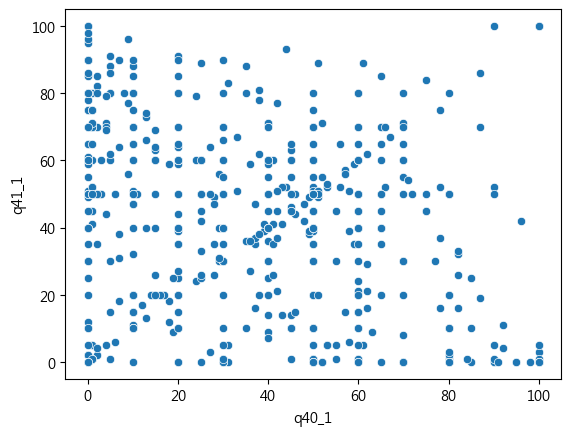

In [21]:
political_party = df.iloc[:, -9:-7]
for col in ['q40_1', 'q41_1']:
    political_party[col]= political_party[col].replace({'非常冰冷':0, '非常溫暖':100}).astype(float)
# political_party = political_party.rename(columns={'q40_1':'國民黨溫暖程度', 'q41_1':'民進黨溫暖程度'})
# political_party.info()
political_party['q40_1']= political_party['q40_1'].replace('非常冰冷', 0)
political_party['q40_1']= political_party['q40_1'].replace('非常溫暖', 100)
political_party['q41_1']= political_party['q41_1'].replace('非常冰冷', 0)
political_party['q41_1']= political_party['q41_1'].replace('非常溫暖', 100)
political_party['q40_1']= pd.to_numeric(political_party['q40_1'])
political_party['q41_1']= pd.to_numeric(political_party['q41_1'])
print(political_party.describe().T)
sns.scatterplot(data=political_party, x='q40_1', y='q41_1')

In [22]:
from scipy import stats

t_stat, p_value = stats.ttest_rel(political_party['q40_1'], political_party['q41_1'])
different = political_party['q40_1']-political_party['q41_1']
mean_q40 = political_party['q40_1'].mean()
mean_q41 = political_party['q41_1'].mean()
mean_different = different.mean()
std_different = different.std(ddof=1)
cohen_d = mean_different/std_different if std_different != 0 else np.nan

print(f"N = {len(political_party)}")
print(f"Mean(Q40_1 國民黨溫度) = {mean_q40:.4f}")
print(f"Mean(Q41_1 民進黨溫度) = {mean_q41:.4f}")
print(f"Mean difference (Q41_1 - Q40_1) = {mean_different:.4f}")
print(f"t = {t_stat:.3f}, p = {p_value:.6f}, 小於0.05有顯著")
# print(f"Cohen's dz (paired) = {cohen_d:.4f}")

N = 685
Mean(Q40_1 國民黨溫度) = 37.0555
Mean(Q41_1 民進黨溫度) = 41.5577
Mean difference (Q41_1 - Q40_1) = -4.5022
t = -2.998, p = 0.002819, 小於0.05有顯著


           N  mean_q40  mean_q41  mean_diff
cluster                                    
0        106     68.45      9.50     -58.95
1        281     51.38     52.03       0.65
2        154      9.92     68.12      58.20
3        144     15.02     16.31       1.29


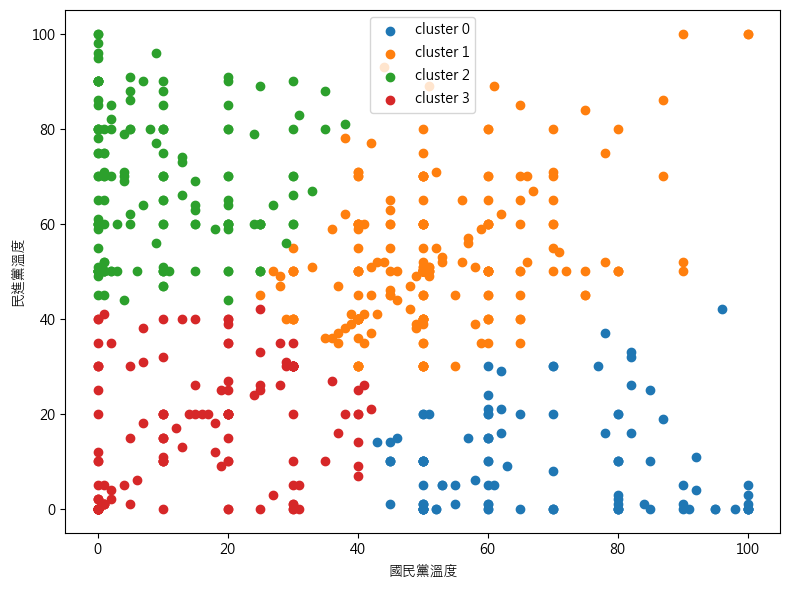

各群均值：
           q40_1    q41_1
cluster                  
0        68.4528   9.5000
1        51.3772  52.0320
2         9.9156  68.1169
3        15.0208  16.3125


In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
X = political_party.to_numpy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
political_party = political_party.assign(cluster=labels)
cluster_summary = (political_party.groupby("cluster").agg(N=("cluster", "size"),
                                                          mean_q40=("q40_1", "mean"),
                                                          mean_q41=("q41_1", "mean"),)
                                                          .assign(mean_diff=lambda d: d["mean_q41"]-d["mean_q40"]).sort_values("cluster"))
print(cluster_summary.round(2))

plt.figure(figsize=(8, 6))
for c in range(4):
    idx = political_party["cluster"] == c
    plt.scatter(political_party.loc[idx, "q40_1"], political_party.loc[idx, "q41_1"], label=f"cluster {c}")
plt.xlabel("國民黨溫度")
plt.ylabel("民進黨溫度")
plt.legend()
plt.tight_layout()
plt.show()

# political_party['cluster'] = political_party['cluster'].replace({0:'親藍', 1:'雙重認同', 2:'親綠', 3:'雙重冷感'})

cluster_means = political_party.groupby("cluster")[['q40_1', 'q41_1']].mean()
print("各群均值：")
print(cluster_means.round(4))



---
---


## 分析

### 信效度分析
- 題目鑑別度
- 題目與整體的概念一致性
- 題目對整體信度的貢獻（拉高還是拉低整體內部一致性）

[Cronbach alpha](https://en.wikipedia.org/wiki/Cronbach%27s_alpha)

[Confidence interval for Cronbach's Alpha](https://search.r-project.org/CRAN/refmans/cocron/html/cronbach.alpha.CI.html)

#### KMO值, Bartelett's test
- 判斷是否適合做 探索性因素分析 (EFA)／主成分分析 (PCA)

- ≥ .90 → Marvelous (極佳)
- .80–.89 → Meritorious
- .70–.79 → Middling
- .60–.69 → Mediocre
- .50–.59 → Miserable
- < .50 → Unacceptable → 不建議做 EFA（探索性因子分析）

---
---

### EDA

In [24]:
full_df = pd.concat([individual[['q1', 'q3','age_g', 'edu_g']], political_party['cluster'], happiness.drop(columns='total'), internet_attack.drop(columns=['total']), cancel_culture['resist_label']],axis=1)

In [25]:
full_df.head(1)

,q1,q3,age_g,edu_g,cluster,q38_01_1,q38_02_1,q39_1,q22_01_1,q22_02_1,q22_03_1,q22_04_1,q22_05_1,q23_01_1,q23_02_1,q23_03_1,q23_04_1,q23_05_1,resist_label
0,女,台北市,中年,研究所以上,1,4,3,4,2,2,2,2,2,1,1,1,1,1,0


In [26]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685 entries, 0 to 684
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   q1            685 non-null    object  
 1   q3            685 non-null    object  
 2   age_g         685 non-null    category
 3   edu_g         685 non-null    object  
 4   cluster       685 non-null    int32   
 5   q38_01_1      685 non-null    int32   
 6   q38_02_1      685 non-null    int32   
 7   q39_1         685 non-null    int32   
 8   q22_01_1      685 non-null    int64   
 9   q22_02_1      685 non-null    int64   
 10  q22_03_1      685 non-null    int64   
 11  q22_04_1      685 non-null    int64   
 12  q22_05_1      685 non-null    int64   
 13  q23_01_1      685 non-null    int64   
 14  q23_02_1      685 non-null    int64   
 15  q23_03_1      685 non-null    int64   
 16  q23_04_1      685 non-null    int64   
 17  q23_05_1      685 non-null    int64   
 18  resist_lab

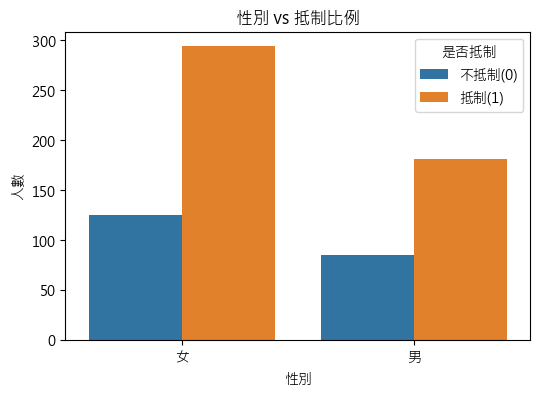

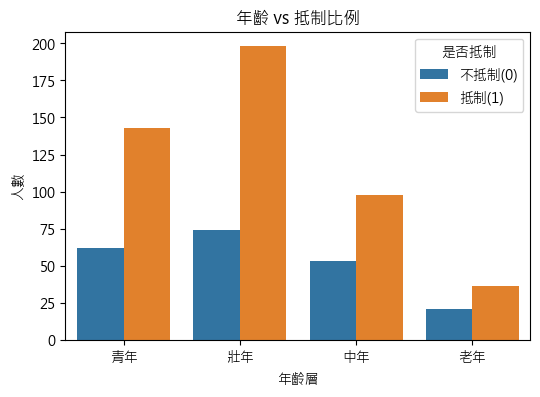

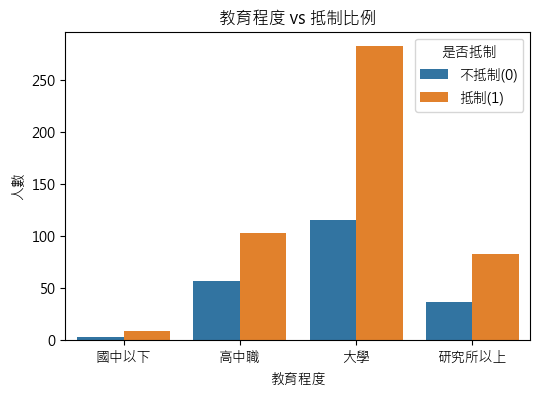

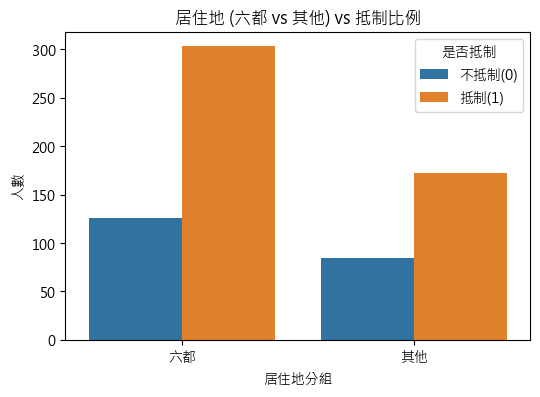

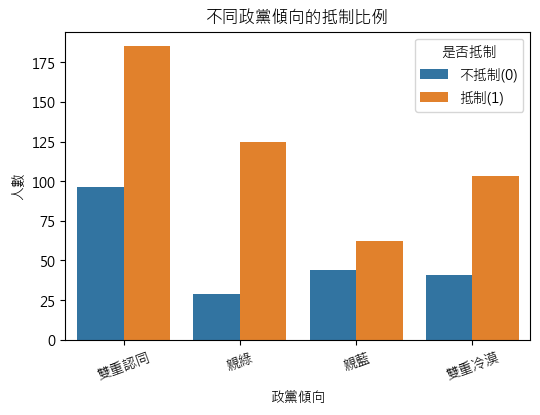

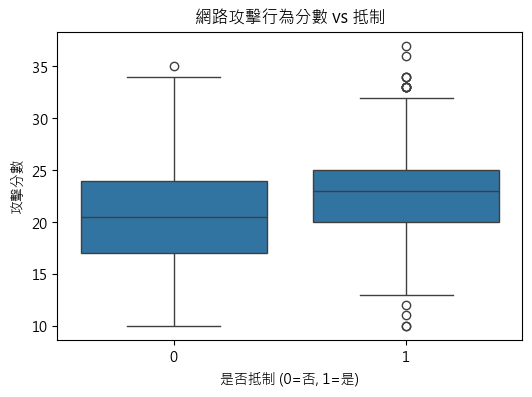

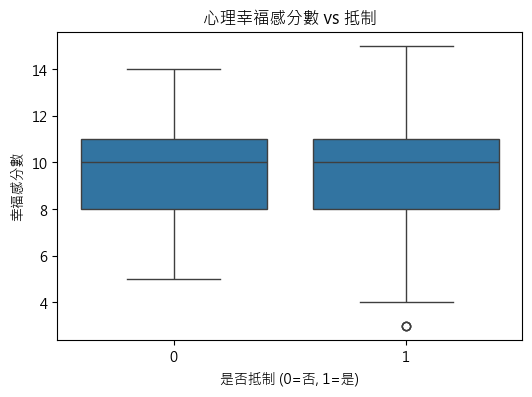

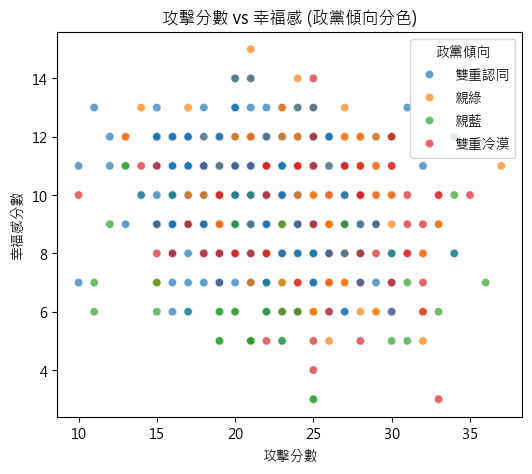

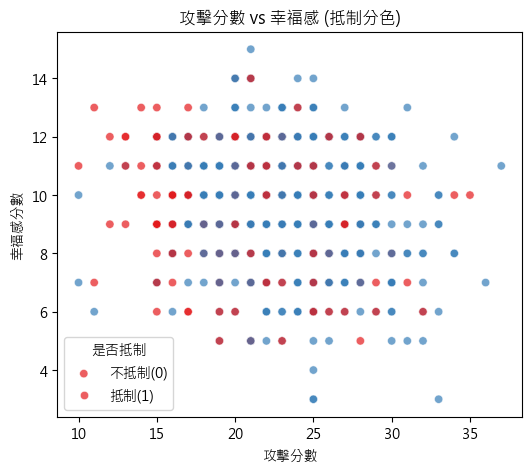

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ====== 前處理 ======

# 居住地分組：六都 vs 其他
six_metros = ["台北市", "新北市", "桃園市", "台中市", "台南市", "高雄市"]
full_df['q3_group'] = full_df['q3'].apply(lambda x: "六都" if x in six_metros else "其他")

# 政黨傾向標籤
cluster_map = {0:'親藍', 1:'雙重認同', 2:'親綠', 3:'雙重冷漠'}
full_df['cluster_label'] = full_df['cluster'].map(cluster_map)

# 建立總分
full_df['attack_score'] = full_df[['q22_01_1','q22_02_1','q22_03_1','q22_04_1','q22_05_1',
                         'q23_01_1','q23_02_1','q23_03_1','q23_04_1','q23_05_1']].sum(axis=1)
full_df['happy_score'] = full_df[['q38_01_1','q38_02_1','q39_1']].sum(axis=1)

# ====== 背景變數圖表 ======

# 1. 性別 vs 抵制比例
plt.figure(figsize=(6,4))
sns.countplot(data=full_df, x='q1', hue='resist_label')
plt.title("性別 vs 抵制比例")
plt.xlabel("性別")
plt.ylabel("人數")
plt.legend(title="是否抵制", labels=["不抵制(0)", "抵制(1)"])
plt.show()

# 2. 年齡 vs 抵制比例
plt.figure(figsize=(6,4))
sns.countplot(data=full_df, x='age_g', hue='resist_label',
              order=["青年","壯年","中年","老年"])
plt.title("年齡 vs 抵制比例")
plt.xlabel("年齡層")
plt.ylabel("人數")
plt.legend(title="是否抵制", labels=["不抵制(0)", "抵制(1)"])
plt.show()

# 3. 教育程度 vs 抵制比例
plt.figure(figsize=(6,4))
sns.countplot(data=full_df, x='edu_g', hue='resist_label',
              order=["國中以下","高中職","大學","研究所以上"])
plt.title("教育程度 vs 抵制比例")
plt.xlabel("教育程度")
plt.ylabel("人數")
plt.legend(title="是否抵制", labels=["不抵制(0)", "抵制(1)"])
plt.show()

# 4. 居住地(六都 vs 其他) vs 抵制比例
plt.figure(figsize=(6,4))
sns.countplot(data=full_df, x='q3_group', hue='resist_label')
plt.title("居住地 (六都 vs 其他) vs 抵制比例")
plt.xlabel("居住地分組")
plt.ylabel("人數")
plt.legend(title="是否抵制", labels=["不抵制(0)", "抵制(1)"])
plt.show()

# ====== 核心變數圖表 ======

# 5. 政黨傾向 vs 抵制比例
plt.figure(figsize=(6,4))
sns.countplot(data=full_df, x='cluster_label', hue='resist_label')
plt.title("不同政黨傾向的抵制比例")
plt.xlabel("政黨傾向")
plt.ylabel("人數")
plt.legend(title="是否抵制", labels=["不抵制(0)","抵制(1)"])
plt.xticks(rotation=20)
plt.show()

# 6. 攻擊分數 vs 抵制 (箱型圖)
plt.figure(figsize=(6,4))
sns.boxplot(data=full_df, x='resist_label', y='attack_score')
plt.title("網路攻擊行為分數 vs 抵制")
plt.xlabel("是否抵制 (0=否, 1=是)")
plt.ylabel("攻擊分數")
plt.show()

# 7. 幸福感 vs 抵制 (箱型圖)
plt.figure(figsize=(6,4))
sns.boxplot(data=full_df, x='resist_label', y='happy_score')
plt.title("心理幸福感分數 vs 抵制")
plt.xlabel("是否抵制 (0=否, 1=是)")
plt.ylabel("幸福感分數")
plt.show()

# 8. 散佈圖 (政黨傾向分色)
plt.figure(figsize=(6,5))
sns.scatterplot(data=full_df, x='attack_score', y='happy_score', hue='cluster_label', alpha=0.7)
plt.title("攻擊分數 vs 幸福感 (政黨傾向分色)")
plt.xlabel("攻擊分數")
plt.ylabel("幸福感分數")
plt.legend(title="政黨傾向")
plt.show()

# 9. 散佈圖 (抵制分色)
plt.figure(figsize=(6,5))
sns.scatterplot(data=full_df, x='attack_score', y='happy_score', hue='resist_label', palette="Set1", alpha=0.7)
plt.title("攻擊分數 vs 幸福感 (抵制分色)")
plt.xlabel("攻擊分數")
plt.ylabel("幸福感分數")
plt.legend(title="是否抵制", labels=["不抵制(0)", "抵制(1)"])
plt.show()


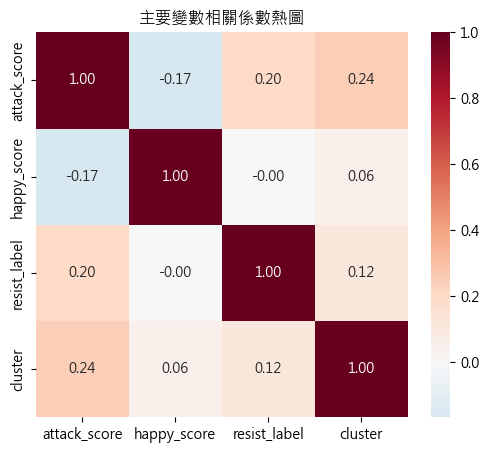

In [28]:
import numpy as np

# ==== 相關係數熱圖 ====
# 取主要變數
corr_vars = ['attack_score', 'happy_score', 'resist_label', 'cluster']
corr_matrix = full_df[corr_vars].corr(method='pearson')

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="RdBu_r", center=0, fmt=".2f")
plt.title("主要變數相關係數熱圖")
plt.show()


In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

core_features = ['cluster', 'attack_score', 'happy_score']
background_features = ['q1', 'age_g', 'edu_g', 'q3_group']
y = full_df['resist_label']

X_core = full_df[core_features]
preprocessor_core = ColumnTransformer(transformers=[('cat', OneHotEncoder(drop='first'), ['cluster']),
                                                    ('sum', StandardScaler(), ['attack_score', 'happy_score'])])

In [30]:
lg = LogisticRegression(max_iter=1000)
pipeline_core= Pipeline(steps=[('preprocessor', preprocessor_core),
                            ('classifier', lg)])
scores_core = cross_val_score(pipeline_core, X_core, y, cv=5, scoring='roc_auc')
print('core_feature AUC mean: ', scores_core.mean())

core_feature AUC mean:  0.6345864661654135


In [31]:
X_all = full_df[core_features + background_features]

# One-hot 對所有類別變數編碼
preprocessor_all = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), ['cluster','q1','age_g','edu_g','q3_group']),
        ('num', StandardScaler(), ['attack_score', 'happy_score'])
    ])

pipe_all = Pipeline(steps=[('preprocessor', preprocessor_all),
                           ('classifier', lg)])

scores_all = cross_val_score(pipe_all, X_all, y, cv=5, scoring='roc_auc')
print("模型 B (核心+背景變數) 平均 AUC:", scores_all.mean())

模型 B (核心+背景變數) 平均 AUC: 0.6310526315789474


AUC: 0.6213231213231214

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.33      0.54      0.41        63
           1       0.72      0.52      0.61       143

    accuracy                           0.53       206
   macro avg       0.53      0.53      0.51       206
weighted avg       0.60      0.53      0.55       206



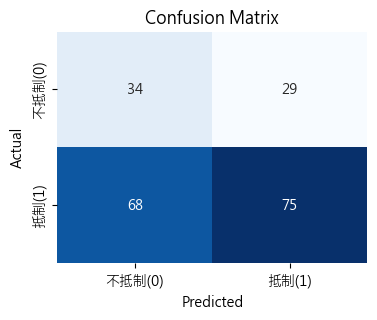

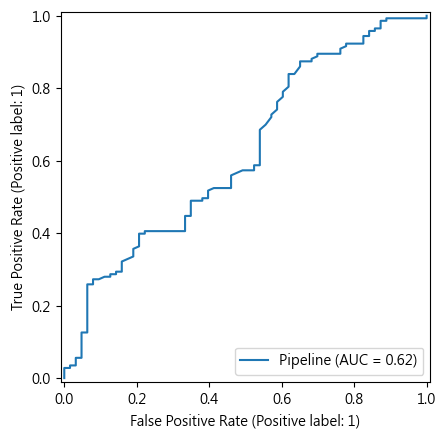

In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# ===== y 與 core features =====
y = full_df['resist_label'].astype(int)
X = full_df[['cluster','attack_score','happy_score']].copy()

# 前處理：cluster one-hot，數值標準化
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), ['cluster']),
        ('num', StandardScaler(), ['attack_score','happy_score'])
    ],
    remainder='drop'
)

# Logistic Regression with balance
log_reg = LogisticRegression(max_iter=100, class_weight='balanced', random_state=123)

# Pipeline
pipe = Pipeline(steps=[('preprocessor', preprocessor),
                      ('classifier', log_reg)])

# ===== Train/Test split =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 訓練模型
pipe.fit(X_train, y_train)

# 預測
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:,1]

# ===== 評估 =====
print("AUC:", roc_auc_score(y_test, y_proba))
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

# 混淆矩陣
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["不抵制(0)","抵制(1)"],
            yticklabels=["不抵制(0)","抵制(1)"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC 曲線
RocCurveDisplay.from_estimator(pipe, X_test, y_test)
plt.show()

In [33]:
import statsmodels.api as sm

# 加上常數項
X = sm.add_constant(X)

# 建模 (帶上 class_weight: balanced -> 需要自己做 sample weight)
# 計算樣本權重：反比於類別數量
class_counts = y.value_counts()
w = y.map({cls: len(y)/count for cls, count in class_counts.items()})

# fit
model = sm.Logit(y, X)
result = model.fit(weights=w)

# summary
print(result.summary())

# 勝算比 (Odds Ratio)
params = result.params
conf = result.conf_int()
or_table = pd.DataFrame({
    "coef": params,
    "OR": params.apply(lambda x: np.exp(x)),
    "2.5%": conf[0].apply(lambda x: np.exp(x)),
    "97.5%": conf[1].apply(lambda x: np.exp(x)),
    "p-value": result.pvalues
})
print("\n=== Odds Ratio Table ===")
print(or_table)

Optimization terminated successfully.
         Current function value: 0.592899
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:           resist_label   No. Observations:                  685
Model:                          Logit   Df Residuals:                      681
Method:                           MLE   Df Model:                            3
Date:                Sun, 17 Aug 2025   Pseudo R-squ.:                 0.03801
Time:                        10:16:24   Log-Likelihood:                -406.14
converged:                       True   LL-Null:                       -422.18
Covariance Type:            nonrobust   LLR p-value:                 4.992e-07
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -1.7316      0.646     -2.681      0.007      -2.997      -0.466
cluster          0.1569

c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\base\optimizer.py:19: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: weights. After release 0.14, this will raise.
  warnings.warn(
